In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt

from segmentation_project.data.loader import ImageLoader
from segmentation_project.ground_truth.overlay import Overlay
from segmentation_project.preprocessing.preprocessing import Grayscale
from segmentation_project.segmentation_models.sam_segmenter import SAMSegmenter

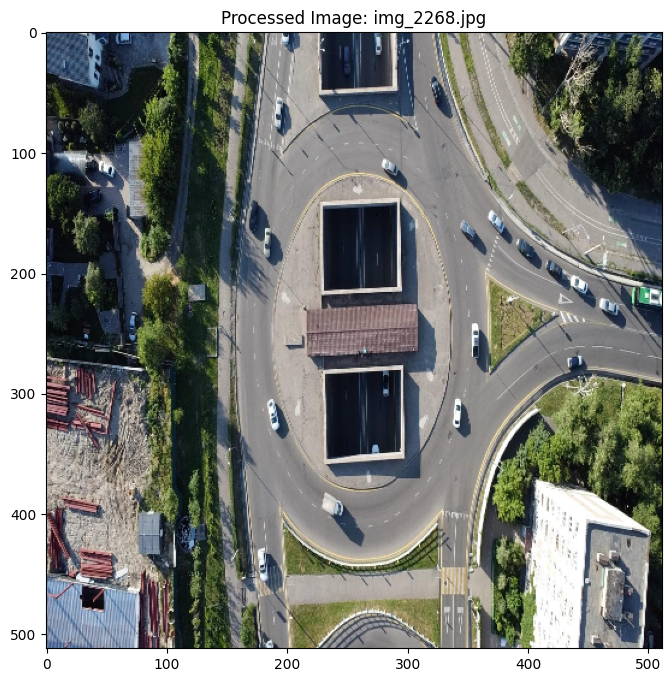

In [2]:
# Initialize loader
loader = ImageLoader()

# List available images
image_paths = loader.list_images()

# Select image index
index = 0  # Change this index to select different images

# Load image
image = loader.load_image(image_paths[index])

# Preprocess image for SAM
processed_image = SAMSegmenter.preprocess_image(image)

# Display processed image

plt.figure(figsize=(12, 8))
plt.imshow(processed_image)
plt.title(f"Processed Image: " f"{image_paths[index].name}")
plt.axis("on")
plt.show()

#### The first execution may take additional time because the SAM checkpoint is downloaded automatically if it is not already available locally. Mask generation is computationally expensive and may run slowly on CPU-only systems.


In [ ]:
# Load SAM model
sam = SAMSegmenter.load_model()

# Generate SAM masks
masks = SAMSegmenter.generate_masks(
    sam=sam,
    image=processed_image,
)

print(f"{len(masks)} masks " f"generated by SAM.")

In [ ]:
# Filter very small masks
small_masks = SAMSegmenter.filter_small_masks(
    masks=masks,
    max_area=250,
)

print(f"{len(small_masks)} " f"small masks retained.")

26 small masks retained.


In [ ]:
# Create binary mask
binary_mask = SAMSegmenter.create_binary_mask(
    image_shape=processed_image.shape,
    masks=small_masks,
)

print("Binary mask created successfully.")

Binary mask created successfully.


In [ ]:
# Convert image to grayscale
grayscale_image = Grayscale.apply(processed_image)

# Create overlay
overlay_image = Overlay.apply(
    grayscale_image=grayscale_image,
    binary_mask=binary_mask,
)

print("Overlay created successfully.")

Overlay created successfully.


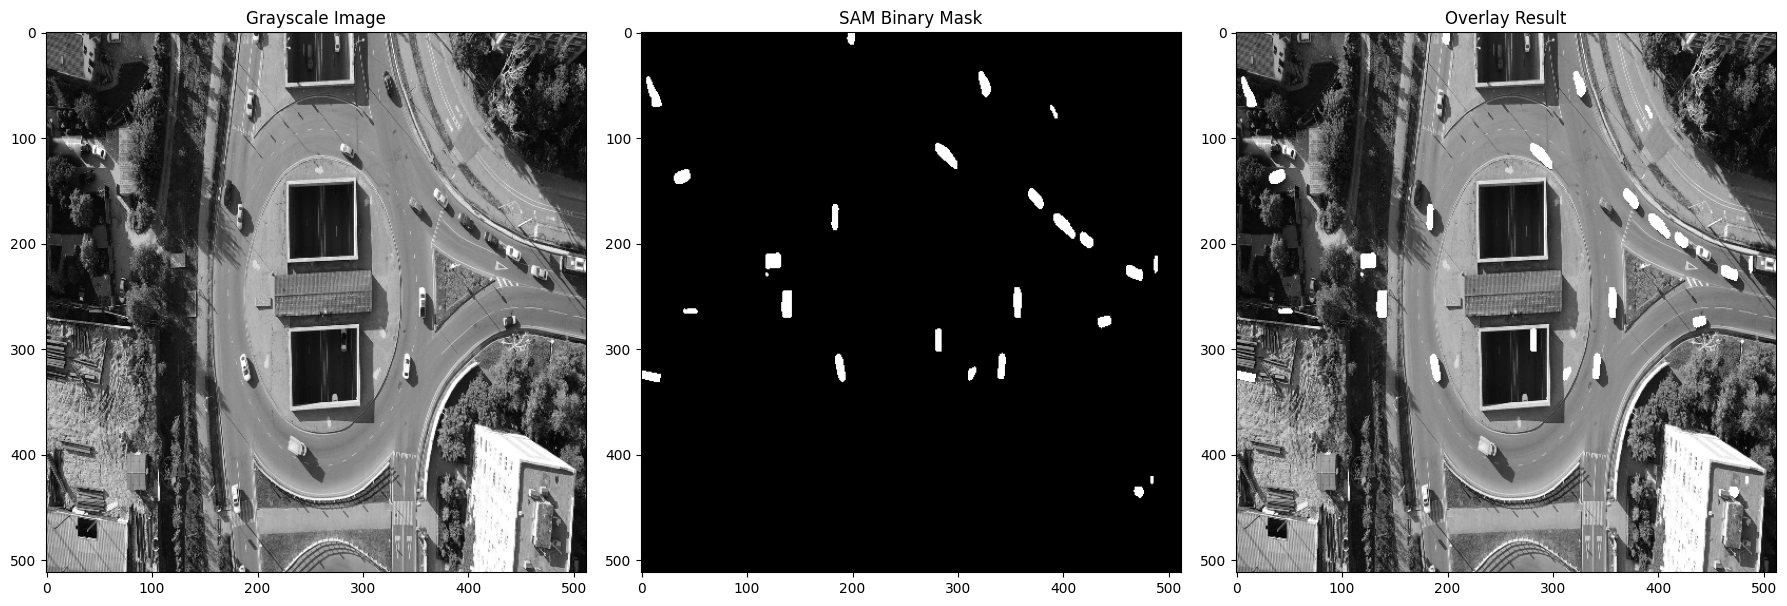

In [ ]:
# Display results side-by-side

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6),
)


# Grayscale image
axes[0].imshow(
    grayscale_image,
    cmap="gray",
)
axes[0].set_title("Grayscale Image")
axes[0].axis("on")


# Binary mask
axes[1].imshow(
    binary_mask,
    cmap="gray",
)
axes[1].set_title("SAM Binary Mask")
axes[1].axis("on")


# Overlay image
axes[2].imshow(
    overlay_image,
    cmap="gray",
)
axes[2].set_title("Overlay Result")
axes[2].axis("on")

plt.tight_layout()
plt.show()

#### If masks_auto already exists in the repository,this block does not need to be rerun as it takes over an hour to run.

In [ ]:
# Create output directory in project root
output_dir = loader.project_root / "masks_auto"

output_dir.mkdir(exist_ok=True)

# Loop through all images
for image_path in image_paths:
    try:
        print(f"\nProcessing: " f"{image_path.name}")

        # Save path
        output_path = output_dir / f"mask_{image_path.stem}.png"

        # Skip if mask already exists
        if output_path.exists():
            print(f"Skipping existing: " f"{output_path.name}")

            continue

        # Load image
        image = loader.load_image(image_path)

        # Preprocess image
        processed_image = SAMSegmenter.preprocess_image(image)

        # Generate SAM masks
        masks = SAMSegmenter.generate_masks(
            sam=sam,
            image=processed_image,
        )

        # Filter small masks
        small_masks = SAMSegmenter.filter_small_masks(
            masks=masks,
            max_area=250,
        )

        # Create binary mask
        binary_mask = SAMSegmenter.create_binary_mask(
            image_shape=processed_image.shape,
            masks=small_masks,
        )

        # Save mask
        cv2.imwrite(
            str(output_path),
            binary_mask,
        )

        print(f"Saved: {output_path}")

    except Exception as error:
        print(f"Skipped {image_path.name}: " f"{error}")